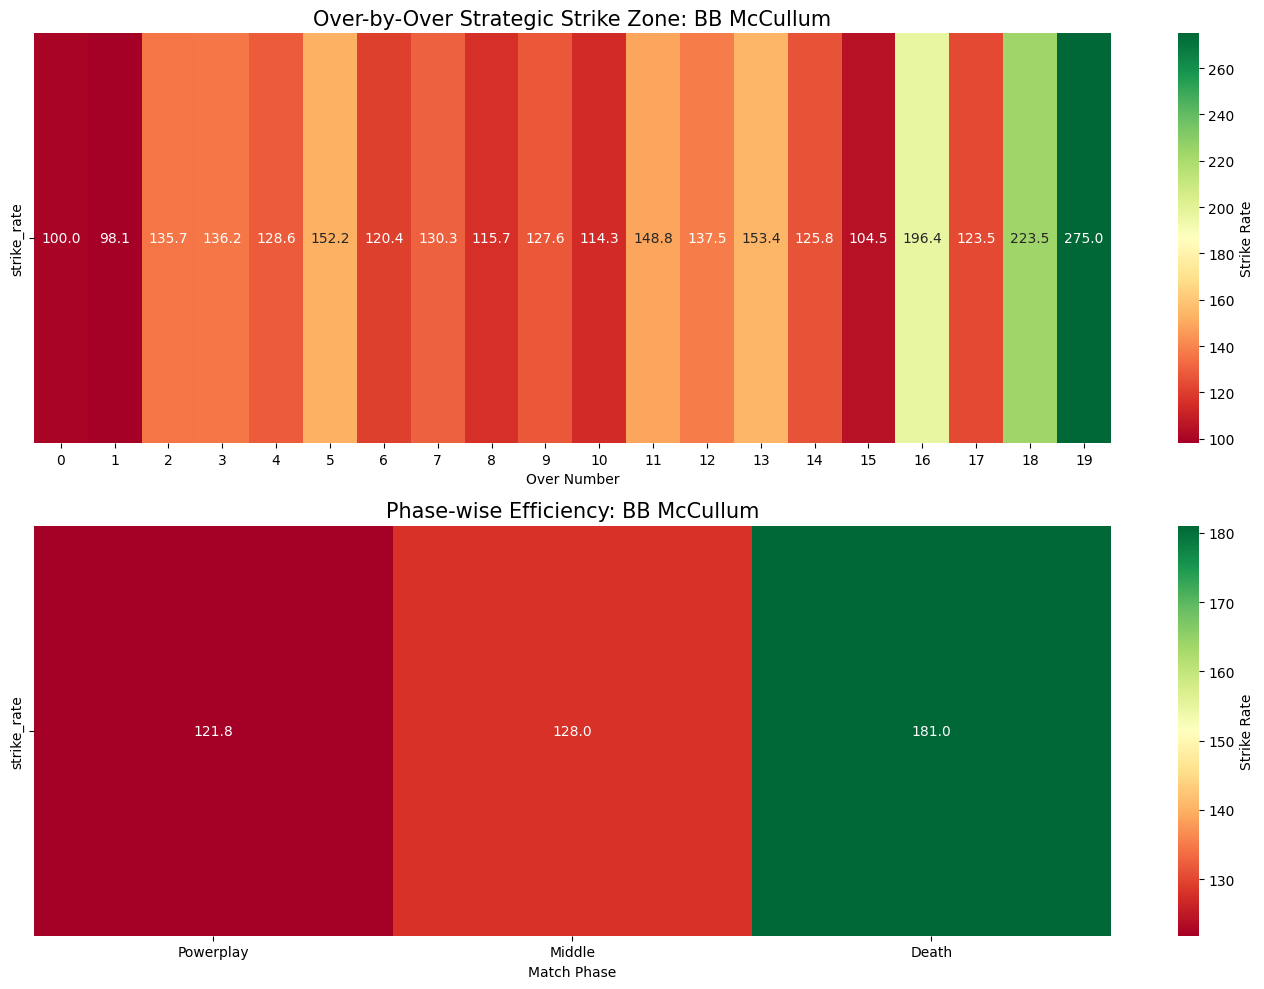

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# Ensure deliveries.csv and matches.csv are in your working directory
deliveries = pd.read_csv('deliveries.csv')

def analyze_batsman_efficiency():
    # 2. Get User Input
    target_batsman = input("Enter the Batsman Name (e.g., BB McCullum): ")
    
    if target_batsman not in deliveries['batter'].unique():
        print("Batsman not found in dataset. Please check spelling.")
        return

    # 3. Data Preparation
    df_batter = deliveries[deliveries['batter'] == target_batsman].copy()
    
    # Categorize Phases
    def get_phase(over):
        if over < 6: return 'Powerplay'
        elif over < 15: return 'Middle'
        else: return 'Death'

    df_batter['phase'] = df_batter['over'].apply(get_phase)

    # 4. Aggregate Over-wise Data
    over_stats = df_batter.groupby('over').agg({'batsman_runs': 'sum', 'ball': 'count'})
    over_stats['strike_rate'] = (over_stats['batsman_runs'] / over_stats['ball']) * 100
    
    # 5. Aggregate Phase-wise Data
    phase_stats = df_batter.groupby('phase').agg({'batsman_runs': 'sum', 'ball': 'count'})
    phase_stats['strike_rate'] = (phase_stats['batsman_runs'] / phase_stats['ball']) * 100
    # Re-ordering for logical progression
    phase_order = ['Powerplay', 'Middle', 'Death']
    phase_stats = phase_stats.reindex(phase_order)

    # 6. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Over-wise Heatmap
    sns.heatmap(over_stats[['strike_rate']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Strike Rate'})
    ax1.set_title(f'Over-by-Over Strategic Strike Zone: {target_batsman}', fontsize=15)
    ax1.set_xlabel('Over Number')
    ax1.set_ylabel('')

    # Phase-wise Heatmap
    sns.heatmap(phase_stats[['strike_rate']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Strike Rate'})
    ax2.set_title(f'Phase-wise Efficiency: {target_batsman}', fontsize=15)
    ax2.set_xlabel('Match Phase')
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()

# Execute the function
analyze_batsman_efficiency()

In [2]:
import pandas as pd
import numpy as np

# Load your dataset
deliveries = pd.read_csv('deliveries.csv')

def predict_runs_in_over():
    # 1. Inputs
    batter_name = input("Enter Batsman Name: ")
    target_over = int(input("Enter Over Number to predict (0-19): "))

    # 2. Filter data for the specific context
    # We filter by both the batter AND the specific over across their entire career
    context_data = deliveries[(deliveries['batter'] == batter_name) & 
                              (deliveries['over'] == target_over)]

    if context_data.empty:
        print(f"No historical data available for {batter_name} in over {target_over}.")
        return

    # 3. Calculate Historical Metrics for Prediction
    total_runs = context_data['batsman_runs'].sum()
    total_balls = context_data['ball'].count()
    
    # Average Runs per Ball in this specific over
    runs_per_ball = total_runs / total_balls
    
    # Strike Rate for this over
    strike_rate = runs_per_ball * 100
    
    # 4. Predict for a full over (assuming the batsman faces all 6 balls)
    predicted_runs = runs_per_ball * 6
    
    # 5. Risk Assessment (Standard Deviation of runs in that over)
    # This tells us if the player is 'Consistent' or 'Volatile' in this over
    match_wise_runs = context_data.groupby('match_id')['batsman_runs'].sum()
    consistency_score = match_wise_runs.std()

    # --- Output Results ---
    print(f"\n--- Prediction Report for {batter_name} (Over {target_over}) ---")
    print(f"Historical Strike Rate in this over: {strike_rate:.2f}")
    print(f"Expected Runs (if facing 6 balls): {predicted_runs:.1f}")
    
    # Descriptive Insight
    if predicted_runs > 10:
        trend = "Aggressive (High Boundary Risk)"
    elif predicted_runs > 6:
        trend = "Steady (Strike Rotation)"
    else:
        trend = "Defensive (Pressure Building)"
        
    print(f"Predicted Batting Style: {trend}")
    print(f"Confidence Interval: +/- {consistency_score:.1f} runs")

# Run the prediction
predict_runs_in_over()


--- Prediction Report for BB McCullum (Over 17) ---
Historical Strike Rate in this over: 123.53
Expected Runs (if facing 6 balls): 7.4
Predicted Batting Style: Steady (Strike Rotation)
Confidence Interval: +/- 2.4 runs


In [4]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split

# # 1. Load Data
# deliveries = pd.read_csv('deliveries.csv')

# # 2. Data Transformation (Aggregating to Over-level)
# # We aggregate to see how many runs a specific batsman scored in a specific over of a specific match
# over_data = deliveries.groupby(['match_id', 'batter', 'batting_team', 'over']).agg({
#     'batsman_runs': 'sum'
# }).reset_index()

# # 3. Encoding Categorical Data
# # Random Forest needs numbers, not names
# le_batter = LabelEncoder()
# le_team = LabelEncoder()

# over_data['batter_id'] = le_batter.fit_transform(over_data['batter'])
# over_data['team_id'] = le_team.fit_transform(over_data['batting_team'])

# # 4. Feature Selection
# # X = [Batter ID, Team ID, Over Number], y = Runs Scored
# X = over_data[['batter_id', 'team_id', 'over']]
# y = over_data['batsman_runs']

# # 5. Training the Model
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X, y)

# def predict_batsman_performance():
#     print("\n--- Random Forest Run Predictor ---")
#     name = input("Enter Batsman Name: ")
#     over_num = int(input("Enter Over Number (0-19): "))

#     try:
#         # Convert input name to the encoded ID
#         name_id = le_batter.transform([name])[0]
        
#         # Get the team ID (using the first team found for this batsman in the data)
#         team_id = over_data[over_data['batter'] == name]['team_id'].iloc[0]
        
#         # Predict
#         prediction = model.predict([[name_id, team_id, over_num]])
        
#         print(f"\nPrediction for {name} in Over {over_num}:")
#         print(f"Expected Runs: {prediction[0]:.2f}")
        
#     except ValueError:
#         print("Error: Batsman name not found in dataset. Please check spelling.")

# # Run the predictor
# predict_batsman_performance()
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Load Data
deliveries = pd.read_csv('deliveries.csv')

# 2. Data Transformation
over_data = deliveries.groupby(['match_id', 'batter', 'batting_team', 'over']).agg({
    'batsman_runs': 'sum'
}).reset_index()

# 3. Encoding Categorical Data
le_batter = LabelEncoder()
le_team = LabelEncoder()

over_data['batter_id'] = le_batter.fit_transform(over_data['batter'])
over_data['team_id'] = le_team.fit_transform(over_data['batting_team'])

# 4. Feature Selection
X = over_data[['batter_id', 'team_id', 'over']]
y = over_data['batsman_runs']

# --- NEW: Train-Test Split (80% Train, 20% Test) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. Training the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Optional: Check accuracy on the test set
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Model Training Complete. Mean Absolute Error: {mae:.2f} runs")

def predict_batsman_performance():
    print("\n--- Random Forest Run Predictor ---")
    name = input("Enter Batsman Name: ")
    over_num = int(input("Enter Over Number (0-19): "))

    try:
        # Convert input name to the encoded ID
        name_id = le_batter.transform([name])[0]
        
        # Get the team ID (using the first team found for this batsman in the data)
        team_id = over_data[over_data['batter'] == name]['team_id'].iloc[0]
        
        # Predict
        input_df = pd.DataFrame(
            [[name_id, team_id, over_num]],
            columns=['batter_id', 'team_id', 'over']
        )

        prediction = model.predict(input_df)
        
        print(f"\nPrediction for {name} in Over {over_num}:")
        print(f"Expected Runs: {prediction[0]:.2f}")
        
    except ValueError:
        print("Error: Batsman name not found in dataset. Please check spelling.")

# Run the predictor
predict_batsman_performance()

Model Training Complete. Mean Absolute Error: 2.94 runs

--- Random Forest Run Predictor ---

Prediction for BB McCullum in Over 19:
Expected Runs: 15.01


C:\Users\rkas3010\AppData\Local\Temp\ipykernel_21644\3996119100.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=over_stats, x='over', y='ball', ax=ax2, palette='viridis')


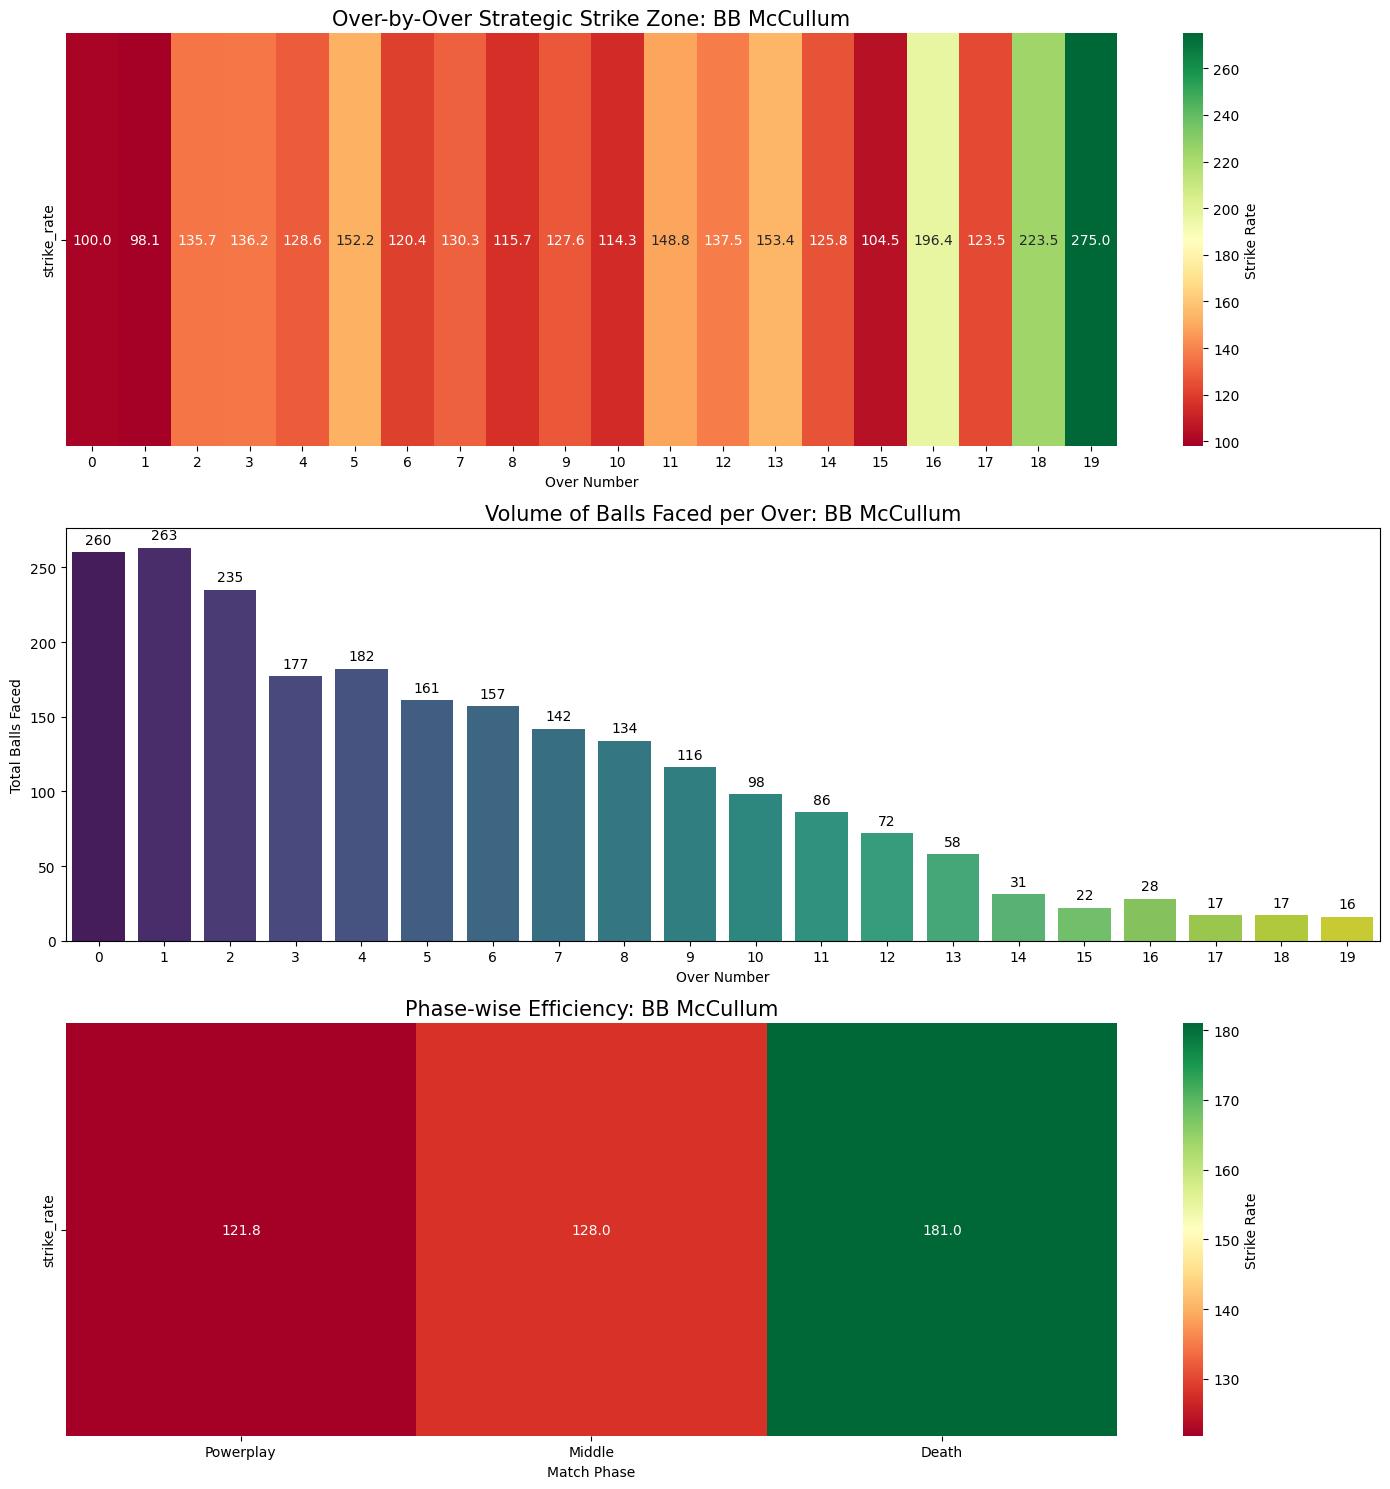

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# Ensure deliveries.csv is in your working directory
deliveries = pd.read_csv('deliveries.csv')

def analyze_batsman_efficiency():
    # 2. Get User Input
    target_batsman = input("Enter the Batsman Name (e.g., BB McCullum): ")
    
    if target_batsman not in deliveries['batter'].unique():
        print("Batsman not found in dataset. Please check spelling.")
        return

    # 3. Data Preparation
    df_batter = deliveries[deliveries['batter'] == target_batsman].copy()
    
    # Categorize Phases
    def get_phase(over):
        if over < 6: return 'Powerplay'
        elif over < 15: return 'Middle'
        else: return 'Death'

    df_batter['phase'] = df_batter['over'].apply(get_phase)

    # 4. Aggregate Over-wise Data
    over_stats = df_batter.groupby('over').agg({'batsman_runs': 'sum', 'ball': 'count'}).reset_index()
    over_stats['strike_rate'] = (over_stats['batsman_runs'] / over_stats['ball']) * 100
    
    # 5. Aggregate Phase-wise Data
    phase_stats = df_batter.groupby('phase').agg({'batsman_runs': 'sum', 'ball': 'count'})
    phase_stats['strike_rate'] = (phase_stats['batsman_runs'] / phase_stats['ball']) * 100
    
    # Re-ordering for logical progression
    phase_order = ['Powerplay', 'Middle', 'Death']
    phase_stats = phase_stats.reindex(phase_order)

    # 6. Visualization (Updated to 3 subplots)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15))
    
    # Plot 1: Over-wise Strike Rate Heatmap
    sns.heatmap(over_stats.set_index('over')[['strike_rate']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Strike Rate'})
    ax1.set_title(f'Over-by-Over Strategic Strike Zone: {target_batsman}', fontsize=15)
    ax1.set_xlabel('Over Number')
    ax1.set_ylabel('')

    # Plot 2: Frequency of Balls Faced per Over (NEW)
    sns.barplot(data=over_stats, x='over', y='ball', ax=ax2, palette='viridis')
    ax2.set_title(f'Volume of Balls Faced per Over: {target_batsman}', fontsize=15)
    ax2.set_xlabel('Over Number')
    ax2.set_ylabel('Total Balls Faced')
    # Adding labels on top of bars
    for p in ax2.patches:
        ax2.annotate(format(p.get_height(), '.0f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

    # Plot 3: Phase-wise Efficiency Heatmap
    sns.heatmap(phase_stats[['strike_rate']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax3, cbar_kws={'label': 'Strike Rate'})
    ax3.set_title(f'Phase-wise Efficiency: {target_batsman}', fontsize=15)
    ax3.set_xlabel('Match Phase')
    ax3.set_ylabel('')

    plt.tight_layout()
    plt.show()

# Execute the function
analyze_batsman_efficiency()

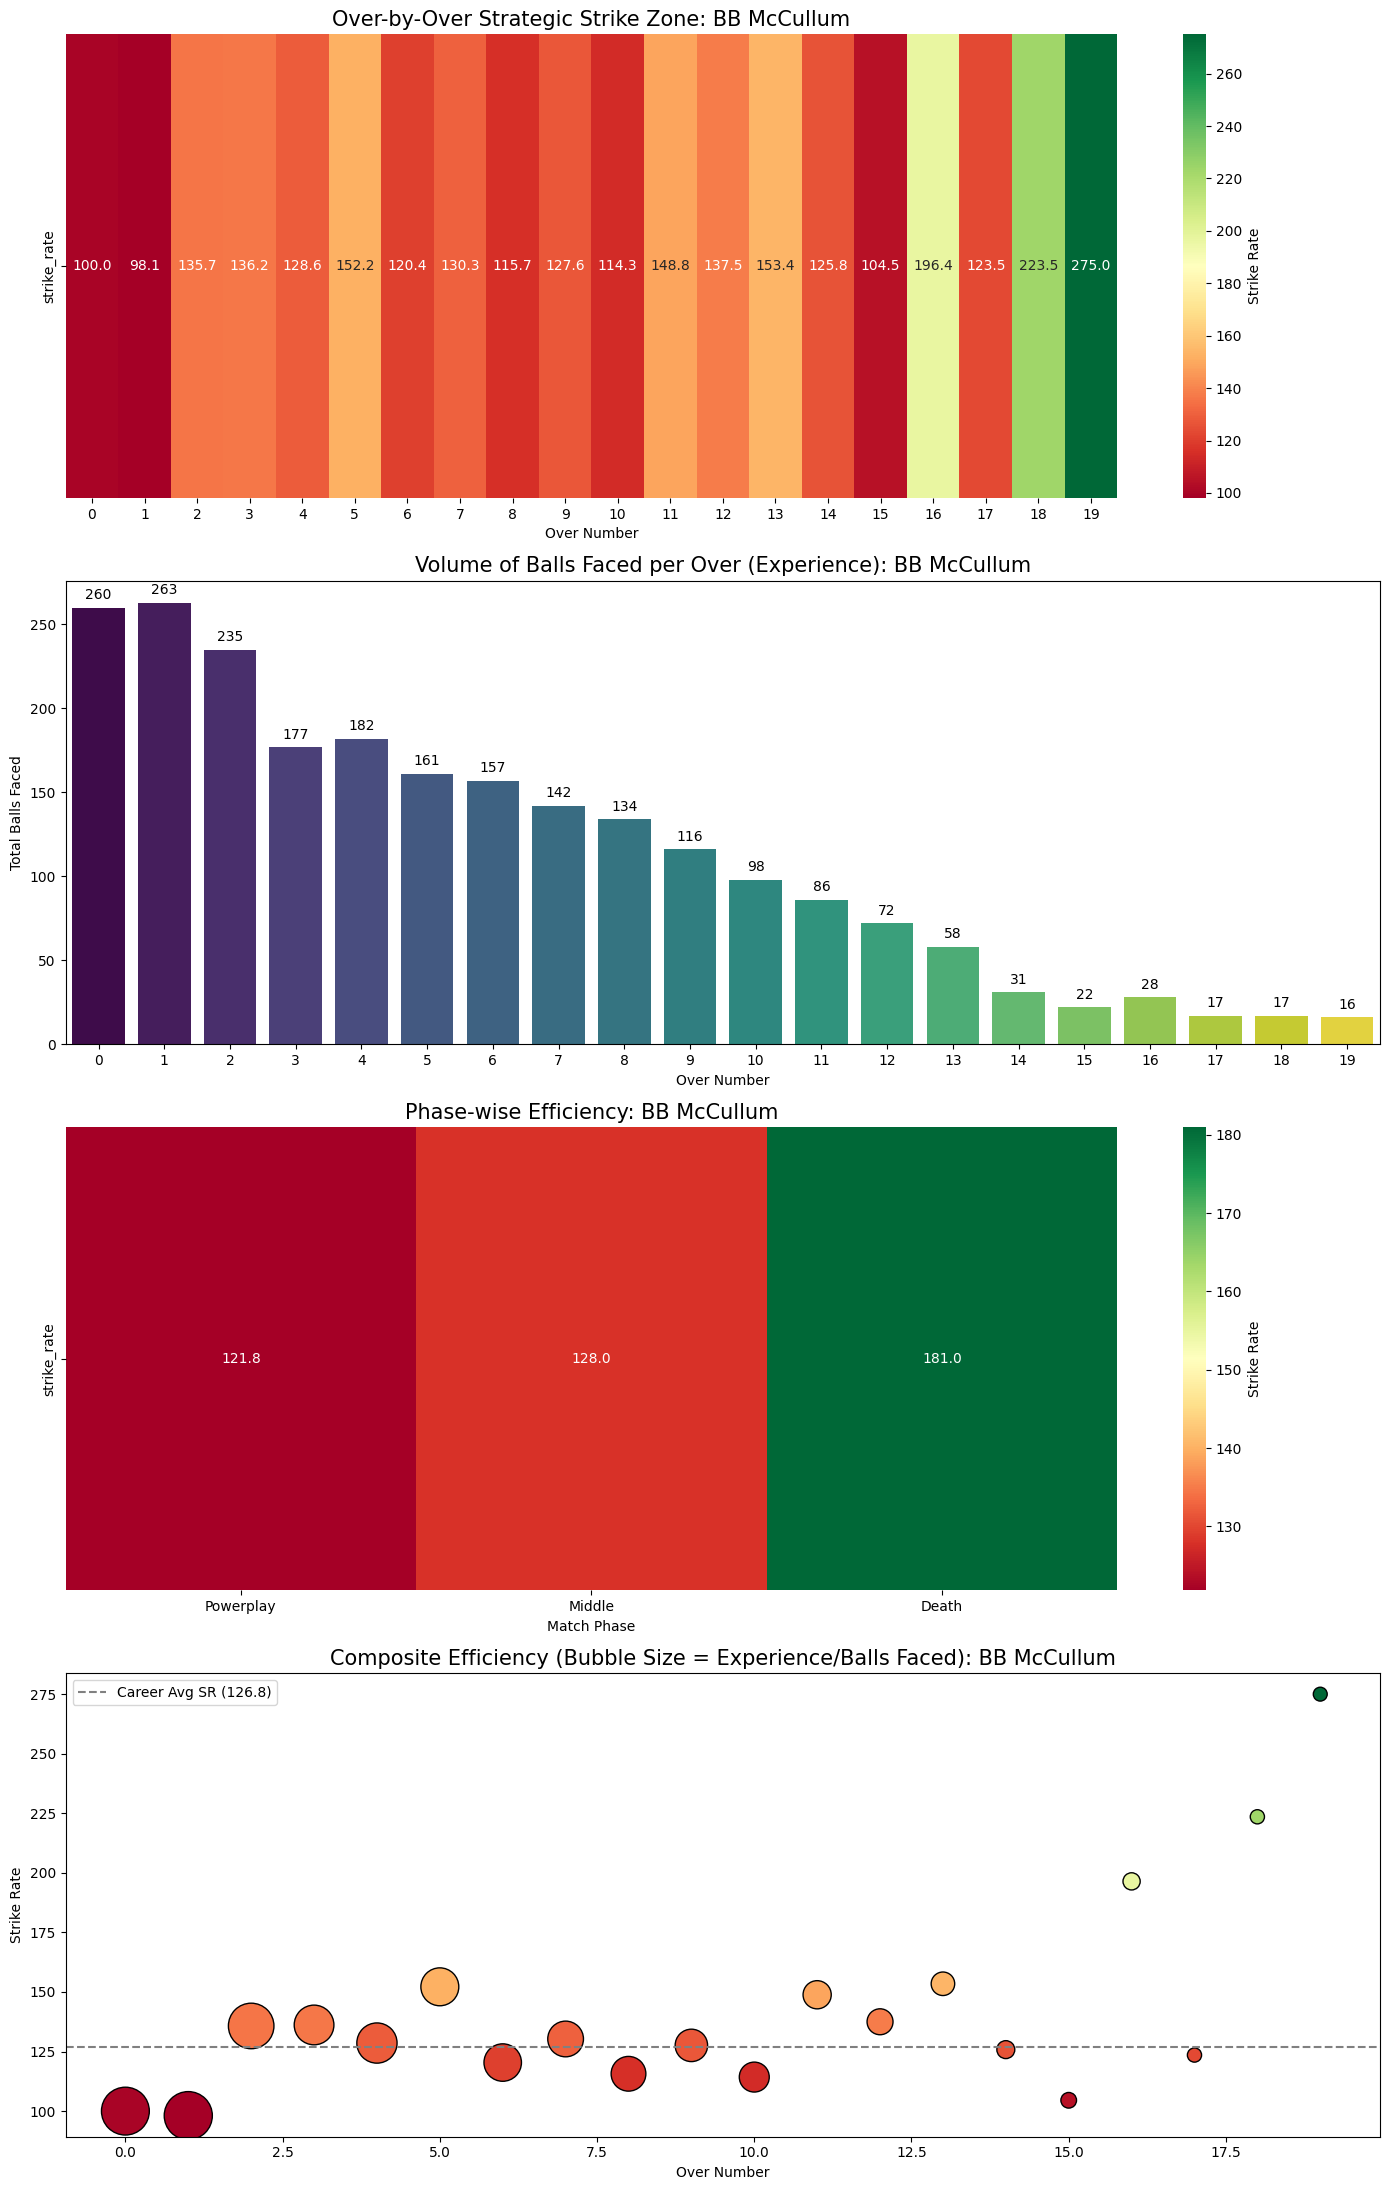

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_batsman_efficiency():
    # 1. Load the data
    try:
        deliveries = pd.read_csv('deliveries.csv')
    except FileNotFoundError:
        print("Error: 'deliveries.csv' not found. Please ensure it is in the same directory.")
        return

    # 2. Get User Input
    target_batsman = input("Enter the Batsman Name (e.g., BB McCullum): ")
    
    if target_batsman not in deliveries['batter'].unique():
        print("Batsman not found in dataset. Please check spelling.")
        return

    # 3. Data Preparation
    df_batter = deliveries[deliveries['batter'] == target_batsman].copy()
    
    # Categorize Phases
    def get_phase(over):
        if over < 6: return 'Powerplay'
        elif over < 15: return 'Middle'
        else: return 'Death'

    df_batter['phase'] = df_batter['over'].apply(get_phase)

    # 4. Aggregate Over-wise Data
    over_stats = df_batter.groupby('over').agg({'batsman_runs': 'sum', 'ball': 'count'}).reset_index()
    over_stats['strike_rate'] = (over_stats['batsman_runs'] / over_stats['ball']) * 100
    
    # 5. Aggregate Phase-wise Data
    phase_stats = df_batter.groupby('phase').agg({'batsman_runs': 'sum', 'ball': 'count'})
    phase_stats['strike_rate'] = (phase_stats['batsman_runs'] / phase_stats['ball']) * 100
    
    # Re-ordering for logical progression
    phase_order = ['Powerplay', 'Middle', 'Death']
    phase_stats = phase_stats.reindex(phase_order)

    # 6. Visualization (Updated to 4 subplots)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 22))
    
    # Plot 1: Over-wise Strike Rate Heatmap
    sns.heatmap(over_stats.set_index('over')[['strike_rate']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Strike Rate'})
    ax1.set_title(f'Over-by-Over Strategic Strike Zone: {target_batsman}', fontsize=15)
    ax1.set_xlabel('Over Number')
    ax1.set_ylabel('')

    # Plot 2: Frequency of Balls Faced per Over (WARNING FIXED)
    # Added hue='over' and legend=False to comply with future seaborn updates
    sns.barplot(data=over_stats, x='over', y='ball', hue='over', ax=ax2, palette='viridis', legend=False)
    ax2.set_title(f'Volume of Balls Faced per Over (Experience): {target_batsman}', fontsize=15)
    ax2.set_xlabel('Over Number')
    ax2.set_ylabel('Total Balls Faced')
    
    # Adding labels on top of bars
    for p in ax2.patches:
        ax2.annotate(format(p.get_height(), '.0f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

    # Plot 3: Phase-wise Efficiency Heatmap
    sns.heatmap(phase_stats[['strike_rate']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax3, cbar_kws={'label': 'Strike Rate'})
    ax3.set_title(f'Phase-wise Efficiency: {target_batsman}', fontsize=15)
    ax3.set_xlabel('Match Phase')
    ax3.set_ylabel('')

    # Plot 4: NEW - Combined Efficiency Analysis (Strike Rate & Experience)
    # Bubble plot where Size = Experience (balls faced), Color = Strike Rate (Red/Green)
    sns.scatterplot(data=over_stats, x='over', y='strike_rate', 
                    size='ball', sizes=(100, 1200), 
                    hue='strike_rate', palette='RdYlGn', 
                    edgecolor='black', linewidth=1,
                    ax=ax4, legend=False)
    
    ax4.set_title(f'Composite Efficiency (Bubble Size = Experience/Balls Faced): {target_batsman}', fontsize=15)
    ax4.set_xlabel('Over Number')
    ax4.set_ylabel('Strike Rate')

    # Add a horizontal line for the "par" strike rate (e.g., 100 or 120 depending on format)
    # Helps visualize which overs are highly efficient
    overall_sr = (df_batter['batsman_runs'].sum() / df_batter['ball'].count()) * 100
    ax4.axhline(overall_sr, color='grey', linestyle='--', label=f'Career Avg SR ({overall_sr:.1f})')
    ax4.legend()

    plt.tight_layout()
    plt.show()

# Execute the function
if __name__ == "__main__":
    analyze_batsman_efficiency()

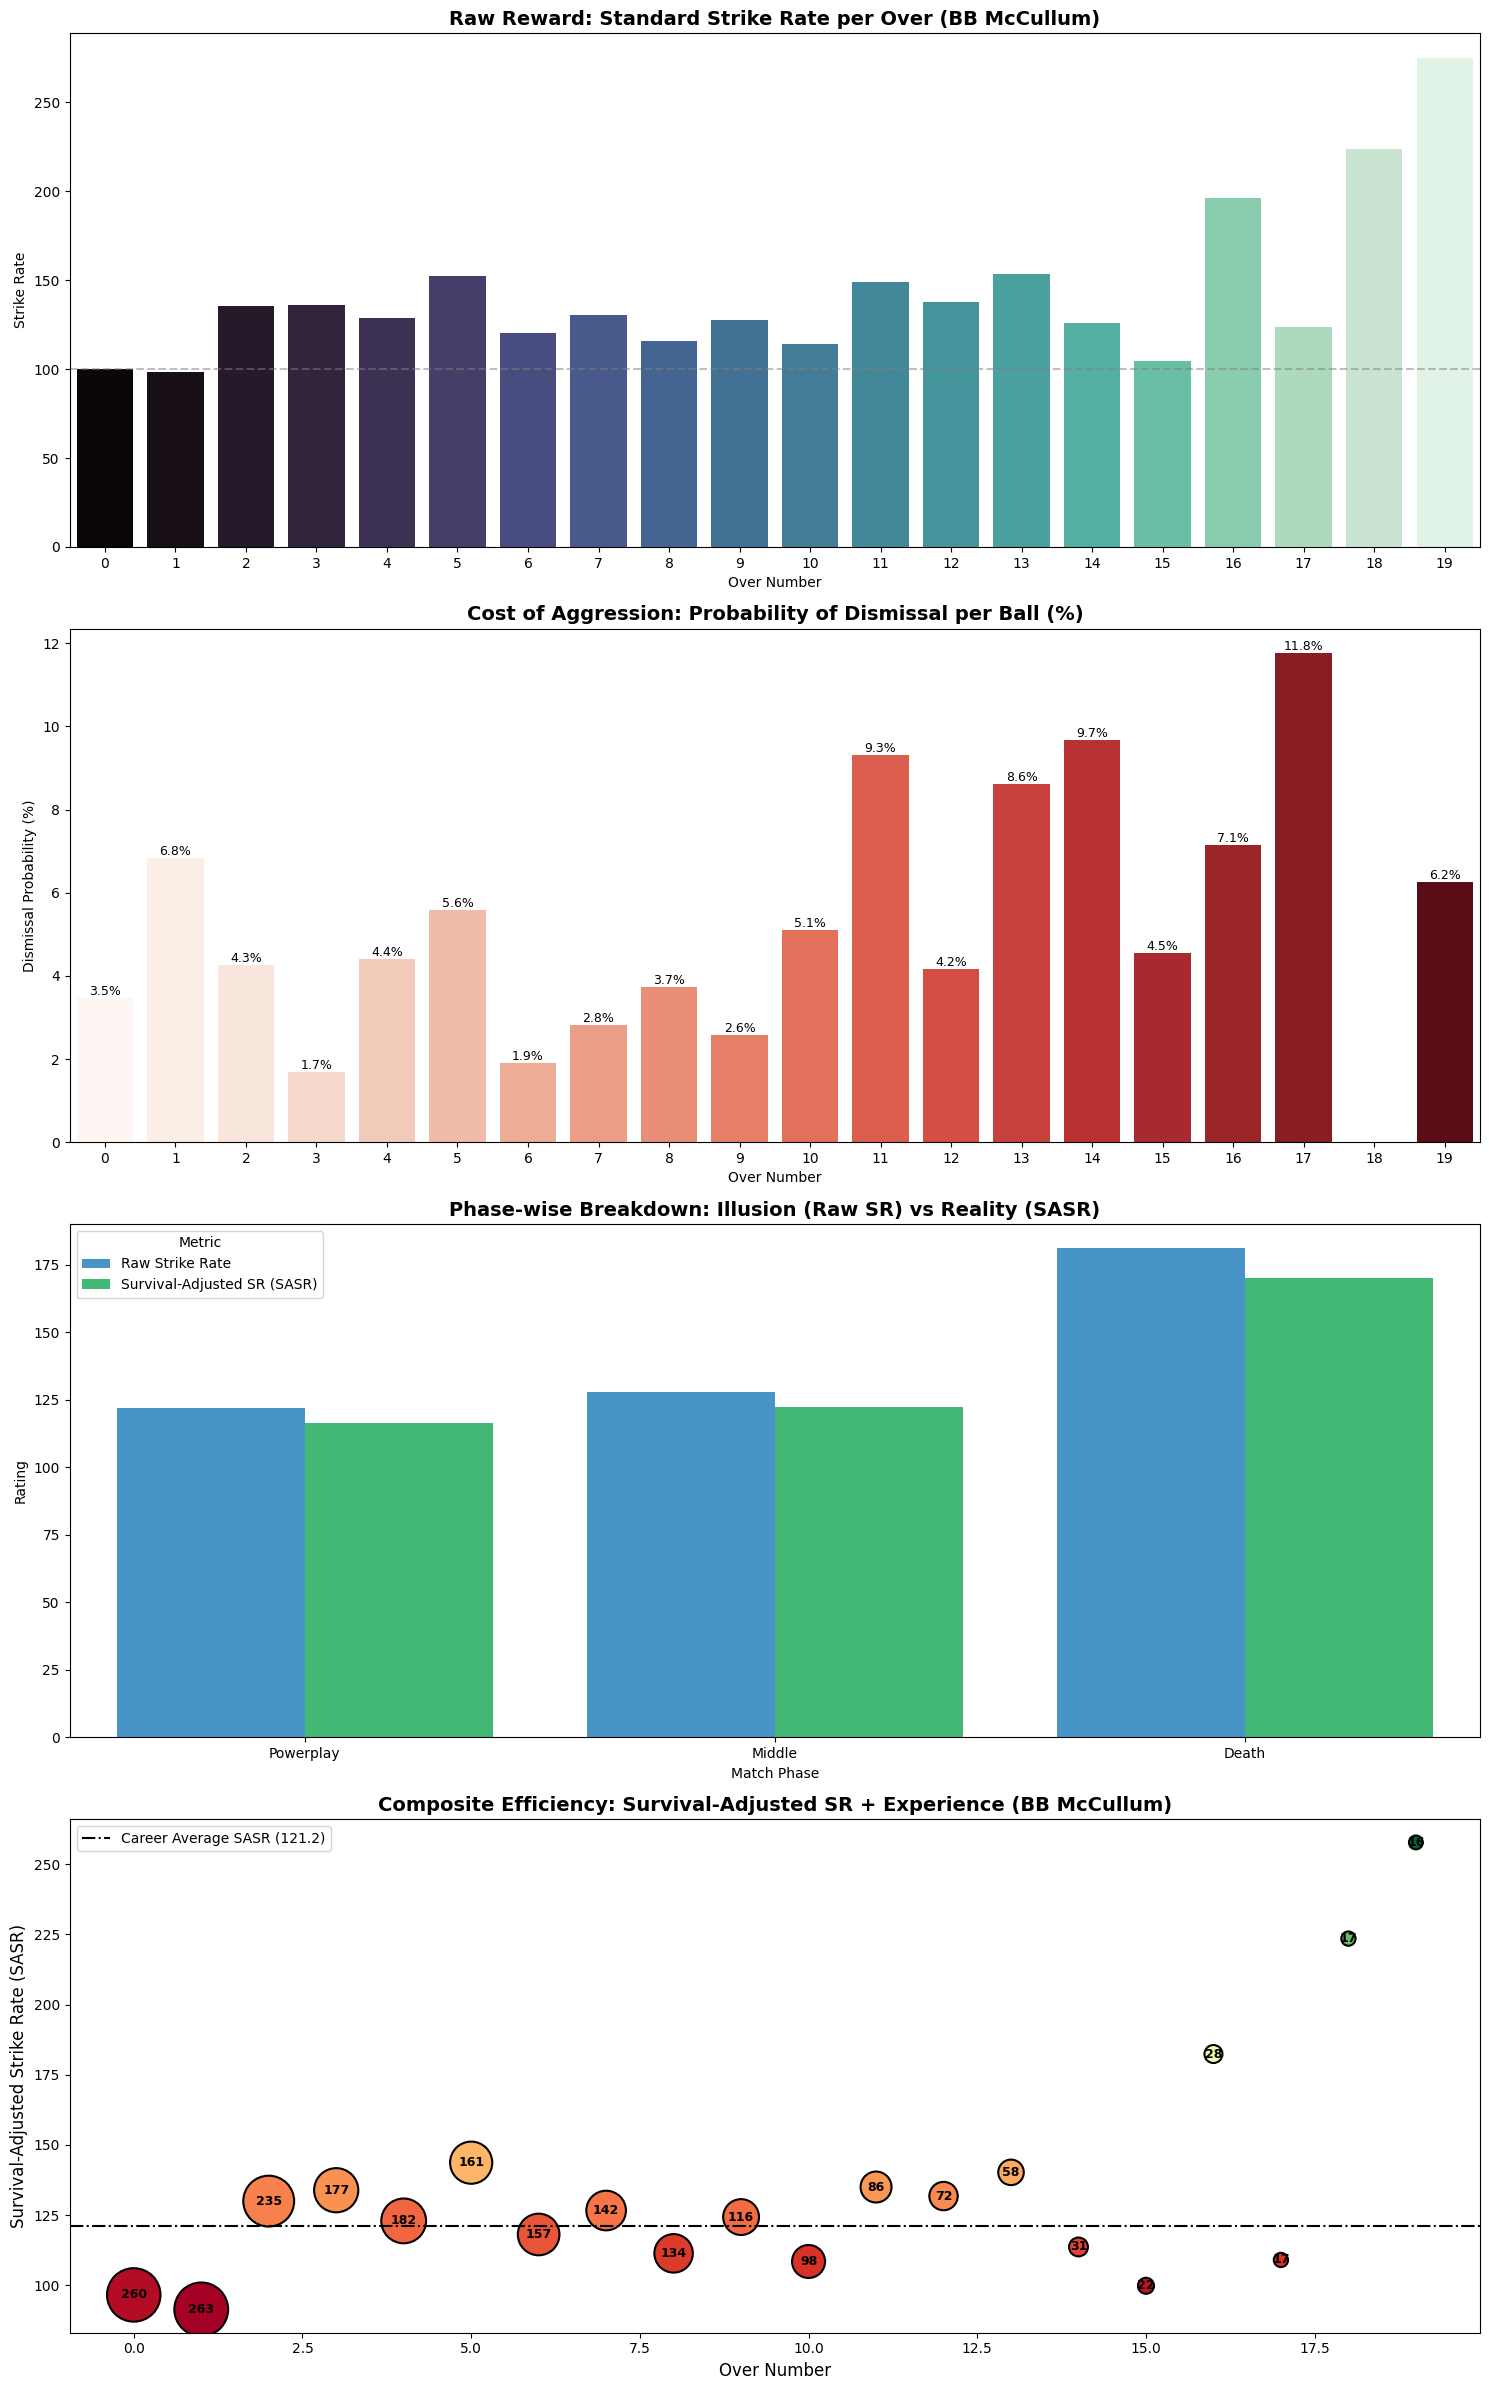

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_risk_adjusted_efficiency():
    # 1. Load the data
    try:
        deliveries = pd.read_csv('deliveries.csv')
    except FileNotFoundError:
        print("Error: 'deliveries.csv' not found. Please ensure it is in the same directory.")
        return

    # Check for dismissal data (crucial for risk analysis)
    if 'player_dismissed' not in deliveries.columns:
        print("Error: Dataset must contain a 'player_dismissed' column to calculate risk.")
        return

    # 2. Get User Input
    target_batsman = input("Enter the Batsman Name (e.g., V Kohli): ")
    
    if target_batsman not in deliveries['batter'].unique():
        print("Batsman not found in dataset. Please check spelling.")
        return

    # 3. Data Preparation
    df_batter = deliveries[deliveries['batter'] == target_batsman].copy()
    
    # Identify dismissals specific to this batsman
    # Handles NaNs and checks if the batsman was the one dismissed on that delivery
    df_batter['is_dismissed'] = (df_batter['player_dismissed'] == target_batsman).astype(int)

    # Categorize Phases
    def get_phase(over):
        if over < 6: return 'Powerplay'
        elif over < 15: return 'Middle'
        else: return 'Death'

    df_batter['phase'] = df_batter['over'].apply(get_phase)

    # 4. Aggregate Over-wise Risk & Reward Data
    over_stats = df_batter.groupby('over').agg(
        runs=('batsman_runs', 'sum'),
        balls=('ball', 'count'),
        dismissals=('is_dismissed', 'sum')
    ).reset_index()
    
    # Calculate Core Metrics
    over_stats['strike_rate'] = (over_stats['runs'] / over_stats['balls']) * 100
    
    # Calculate Risk Metrics (Cost of Aggression)
    over_stats['dismissal_rate'] = over_stats['dismissals'] / over_stats['balls']
    over_stats['survival_rate'] = 1 - over_stats['dismissal_rate']
    
    # Calculate Composite Efficiency: Survival-Adjusted Strike Rate (SASR)
    over_stats['sasr'] = over_stats['strike_rate'] * over_stats['survival_rate']

    # 5. Aggregate Phase-wise Data for Summary
    phase_stats = df_batter.groupby('phase').agg(
        runs=('batsman_runs', 'sum'),
        balls=('ball', 'count'),
        dismissals=('is_dismissed', 'sum')
    )
    phase_stats['strike_rate'] = (phase_stats['runs'] / phase_stats['balls']) * 100
    phase_stats['survival_rate'] = 1 - (phase_stats['dismissals'] / phase_stats['balls'])
    phase_stats['sasr'] = phase_stats['strike_rate'] * phase_stats['survival_rate']
    
    # Re-order phases
    phase_order = ['Powerplay', 'Middle', 'Death']
    phase_stats = phase_stats.reindex(phase_order)

    # 6. Visualization (4 Dynamic Subplots)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 24))
    
    # Plot 1: Standard Strike Rate (The Raw Reward)
    sns.barplot(data=over_stats, x='over', y='strike_rate', hue='over', ax=ax1, palette='mako', legend=False)
    ax1.set_title(f'Raw Reward: Standard Strike Rate per Over ({target_batsman})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Over Number')
    ax1.set_ylabel('Strike Rate')
    ax1.axhline(100, color='grey', linestyle='--', alpha=0.5)

    # Plot 2: Dismissal Probability (The Cost of Aggression)
    # Convert to percentage for readability
    over_stats['out_prob_pct'] = over_stats['dismissal_rate'] * 100
    sns.barplot(data=over_stats, x='over', y='out_prob_pct', hue='over', ax=ax2, palette='Reds', legend=False)
    ax2.set_title(f'Cost of Aggression: Probability of Dismissal per Ball (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Over Number')
    ax2.set_ylabel('Dismissal Probability (%)')
    
    # Adding data labels to the risk chart
    for p in ax2.patches:
        height = p.get_height()
        if height > 0:
            ax2.annotate(f'{height:.1f}%', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=9)

    # Plot 3: Phase-wise True Efficiency (SASR vs Standard SR)
    # Melting data to plot side-by-side bars
    phase_melted = phase_stats[['strike_rate', 'sasr']].reset_index().melt(id_vars='phase', var_name='Metric', value_name='Value')
    sns.barplot(data=phase_melted, x='phase', y='Value', hue='Metric', ax=ax3, palette=['#3498db', '#2ecc71'])
    ax3.set_title(f'Phase-wise Breakdown: Illusion (Raw SR) vs Reality (SASR)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Match Phase')
    ax3.set_ylabel('Rating')
    # Customizing legend labels
    handles, labels = ax3.get_legend_handles_labels()
    ax3.legend(handles=handles, labels=['Raw Strike Rate', 'Survival-Adjusted SR (SASR)'], title='Metric')

    # Plot 4: THE MASTER COMPOSITE (SASR + Experience)
    # Bubble plot where Y = SASR, Size = Balls Faced, Color = SASR Value
    scatter = sns.scatterplot(data=over_stats, x='over', y='sasr', 
                              size='balls', sizes=(100, 1500), 
                              hue='sasr', palette='RdYlGn', 
                              edgecolor='black', linewidth=1.5,
                              ax=ax4, legend=False)
    
    ax4.set_title(f'Composite Efficiency: Survival-Adjusted SR + Experience ({target_batsman})', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Over Number', fontsize=12)
    ax4.set_ylabel('Survival-Adjusted Strike Rate (SASR)', fontsize=12)

    # Add baseline for comparison (Overall Career SASR)
    overall_sr = (over_stats['runs'].sum() / over_stats['balls'].sum()) * 100
    overall_survival = 1 - (over_stats['dismissals'].sum() / over_stats['balls'].sum())
    career_sasr = overall_sr * overall_survival
    
    ax4.axhline(career_sasr, color='black', linestyle='-.', label=f'Career Average SASR ({career_sasr:.1f})')
    ax4.legend(loc='upper left')

    # Add text annotations inside the bubbles to show exact balls faced
    for i in range(len(over_stats)):
        if over_stats['balls'].iloc[i] > 0: # Only annotate if they've faced balls
            ax4.text(over_stats['over'].iloc[i], over_stats['sasr'].iloc[i], 
                     str(over_stats['balls'].iloc[i]), 
                     horizontalalignment='center', verticalalignment='center', 
                     color='black', fontsize=9, weight='bold')

    plt.tight_layout()
    plt.show()

# Execute the function
if __name__ == "__main__":
    analyze_risk_adjusted_efficiency()

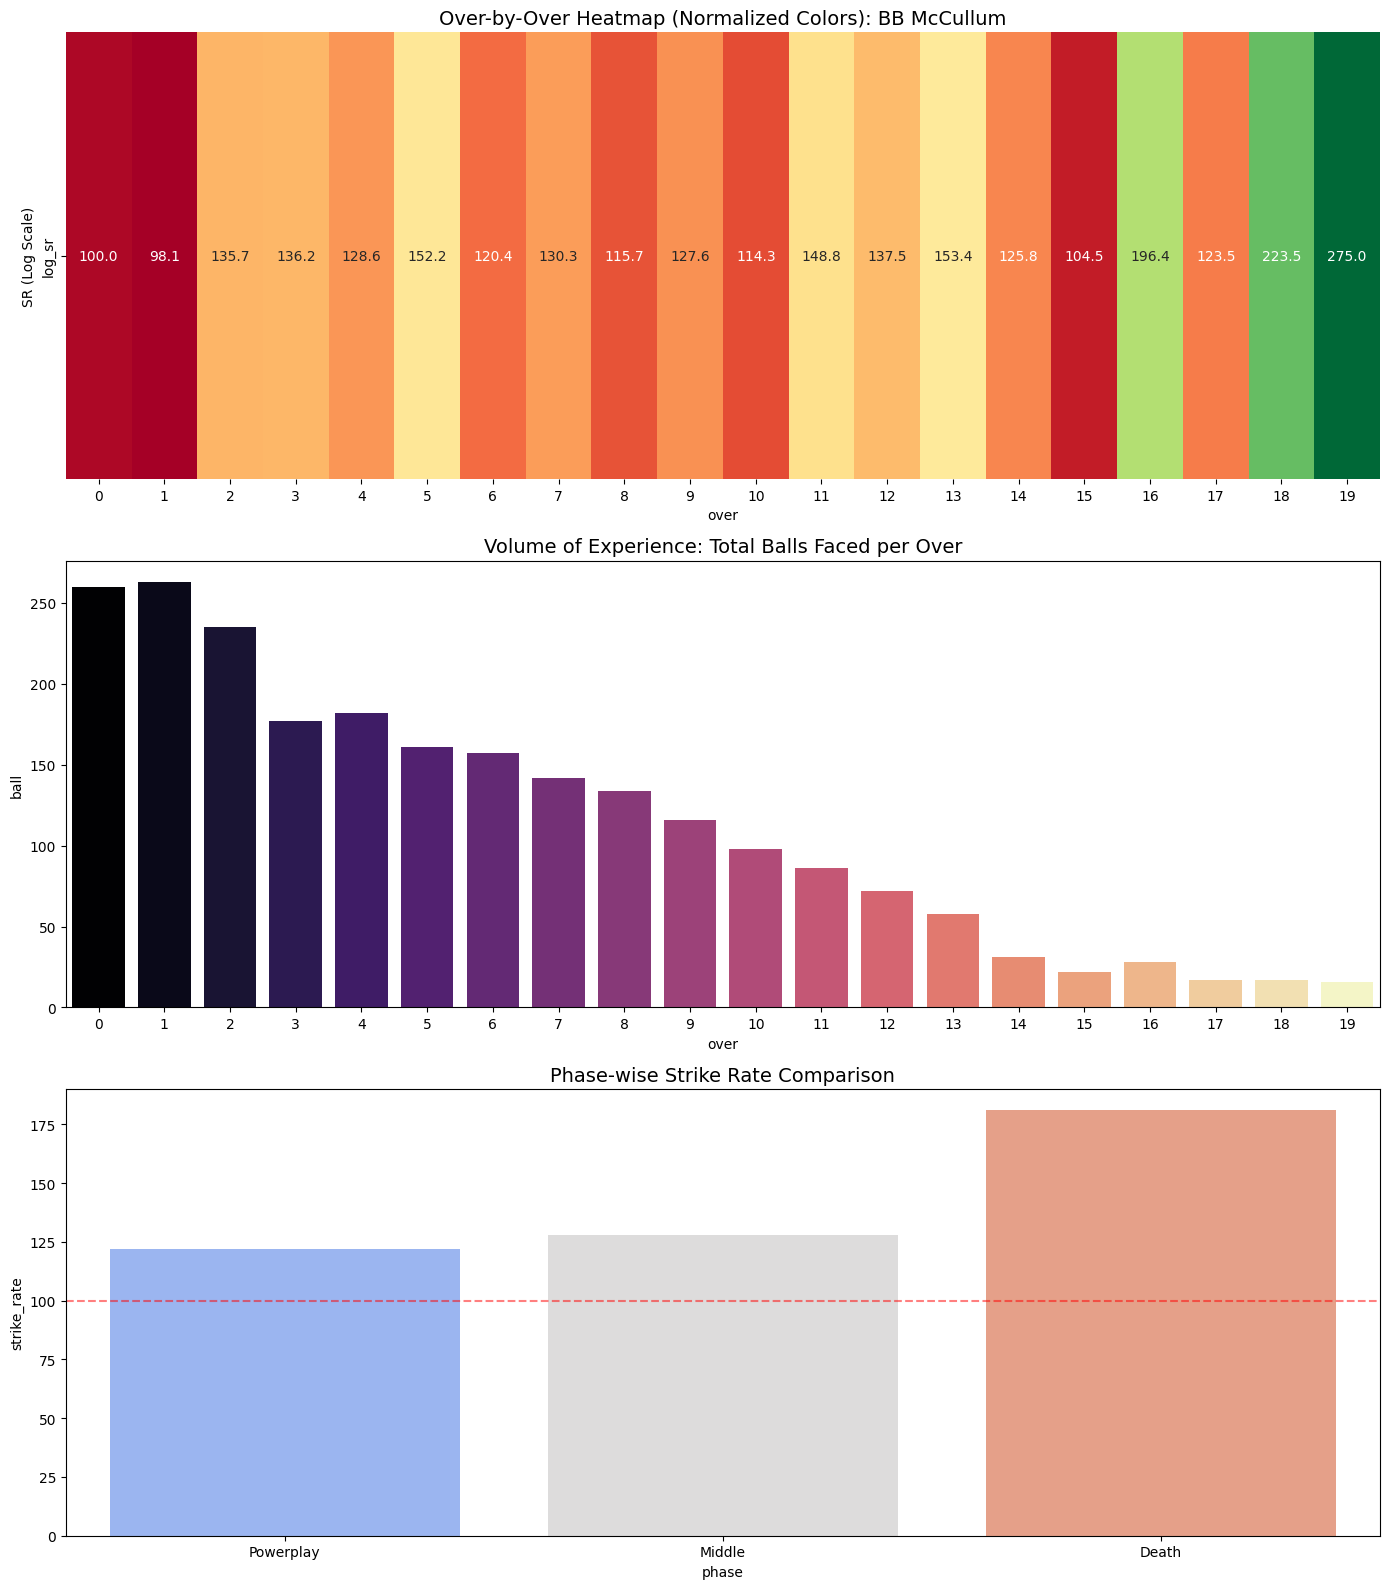

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data
deliveries = pd.read_csv('deliveries.csv')

def analyze_batsman_efficiency():
    # 2. Get User Input
    target_batsman = input("Enter the Batsman Name: ")
    
    if target_batsman not in deliveries['batter'].unique():
        print(f"Error: '{target_batsman}' not found in dataset.")
        return

    # 3. Data Preparation
    df_batter = deliveries[deliveries['batter'] == target_batsman].copy()
    
    def get_phase(over):
        if over < 6: return 'Powerplay'
        elif over < 15: return 'Middle'
        else: return 'Death'

    df_batter['phase'] = df_batter['over'].apply(get_phase)

    # 4. Aggregate Over-wise Data & Handle Missing Overs
    over_stats = df_batter.groupby('over').agg({'batsman_runs': 'sum', 'ball': 'count'})
    
    # Reindex to include all 20 overs (0-19) even if not played
    all_overs = pd.Index(range(20), name='over')
    over_stats = over_stats.reindex(all_overs).fillna(0).reset_index()
    
    # Calculate Strike Rate (handle division by zero)
    over_stats['strike_rate'] = (over_stats['batsman_runs'] / over_stats['ball'] * 100).fillna(0)
    
    # 5. Transform Data to reduce skewness (Log Transformation for Heatmap)
    # Adding 1 to avoid log(0)
    over_stats['log_sr'] = np.log1p(over_stats['strike_rate'])

    # 6. Aggregate Phase-wise Data
    phase_stats = df_batter.groupby('phase').agg({'batsman_runs': 'sum', 'ball': 'count'})
    phase_order = ['Powerplay', 'Middle', 'Death']
    phase_stats = phase_stats.reindex(phase_order).fillna(0)
    phase_stats['strike_rate'] = (phase_stats['batsman_runs'] / phase_stats['ball'] * 100).fillna(0)

    # 7. Visualization
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 16))
    
    # Plot 1: Heatmap (Using Log-transformed data for better color distribution)
    sns.heatmap(over_stats.set_index('over')[['log_sr']].T, annot=over_stats.set_index('over')[['strike_rate']].T, 
                fmt=".1f", cmap='RdYlGn', ax=ax1, cbar=False)
    ax1.set_title(f'Over-by-Over Heatmap (Normalized Colors): {target_batsman}', fontsize=14)
    ax1.set_ylabel('SR (Log Scale)')

    # Plot 2: Volume of Balls (Shows if data is statistically significant)
    sns.barplot(data=over_stats, x='over', y='ball', ax=ax2, palette='magma', hue='over', legend=False)
    ax2.set_title('Volume of Experience: Total Balls Faced per Over', fontsize=14)
    
    # Plot 3: Phase-wise Efficiency
    sns.barplot(x=phase_stats.index, y=phase_stats['strike_rate'], ax=ax3, palette='coolwarm', hue=phase_stats.index, legend=False)
    ax3.set_title('Phase-wise Strike Rate Comparison', fontsize=14)
    ax3.axhline(100, color='red', linestyle='--', alpha=0.5) # Benchmark line

    plt.tight_layout()
    plt.show()

analyze_batsman_efficiency()

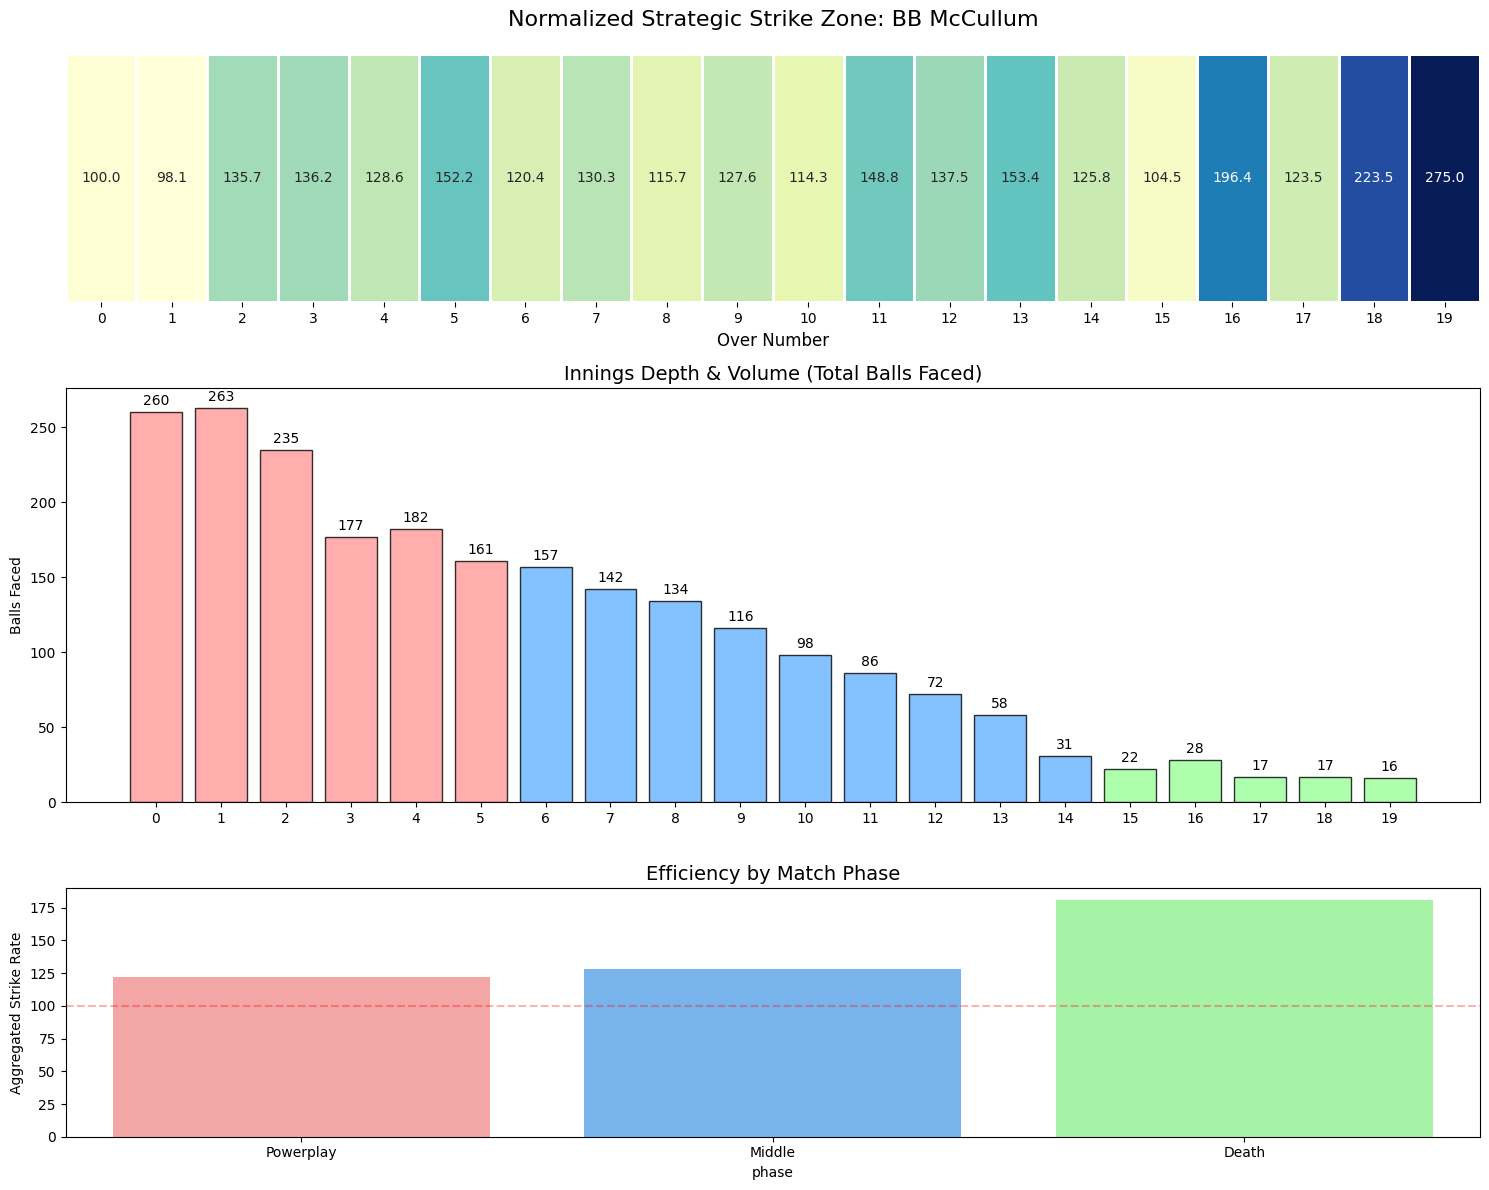

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. Load the data
try:
    deliveries = pd.read_csv('deliveries.csv')
except FileNotFoundError:
    print("Error: 'deliveries.csv' not found. Please check your directory.")

def analyze_batsman_efficiency():
    # 2. Get User Input
    target_batsman = input("Enter the Batsman Name (e.g., V Kohli): ")
    
    if target_batsman not in deliveries['batter'].unique():
        print(f"'{target_batsman}' not found. Please verify the name in the dataset.")
        return

    # 3. Filter and Prepare Data
    df_batter = deliveries[deliveries['batter'] == target_batsman].copy()
    
    # Define phases
    def get_phase(over):
        if over < 6: return 'Powerplay'
        elif over < 15: return 'Middle'
        else: return 'Death'
    df_batter['phase'] = df_batter['over'].apply(get_phase)

    # 4. Comprehensive Reindexing (Handles players who haven't played all 20 overs)
    # Create a template for all 20 overs
    all_overs = pd.DataFrame({'over': range(20)})
    
    over_stats = df_batter.groupby('over').agg(
        total_runs=('batsman_runs', 'sum'),
        total_balls=('ball', 'count')
    ).reset_index()
    
    # Merge with template to fill missing overs with 0
    over_stats = pd.merge(all_overs, over_stats, on='over', how='left').fillna(0)
    
    # Calculate Strike Rate (Handle division by zero)
    over_stats['strike_rate'] = np.where(
        over_stats['total_balls'] > 0, 
        (over_stats['total_runs'] / over_stats['total_balls']) * 100, 
        0
    )

    # 5. Transform Data to Fix Skewness
    # We use Log transformation for the color mapping to normalize extreme outliers
    # while keeping the actual values for text annotations
    over_stats['color_intensity'] = np.log1p(over_stats['strike_rate'])

    # Phase-wise Aggregation
    phase_order = ['Powerplay', 'Middle', 'Death']
    phase_stats = df_batter.groupby('phase').agg(
        total_runs=('batsman_runs', 'sum'),
        total_balls=('ball', 'count')
    ).reindex(phase_order).fillna(0)
    
    phase_stats['strike_rate'] = np.where(
        phase_stats['total_balls'] > 0, 
        (phase_stats['total_runs'] / phase_stats['total_balls']) * 100, 
        0
    )

    # 6. Visualization
    plt.style.use('seaborn-v0_8-muted')
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 2, 1.2])
    
    # Plot 1: The "Normalized" Heatmap
    ax1 = fig.add_subplot(gs[0])
    sns.heatmap(
        over_stats.set_index('over')[['color_intensity']].T, 
        annot=over_stats.set_index('over')[['strike_rate']].T, # Display actual SR
        fmt=".1f", 
        cmap='YlGnBu', 
        ax=ax1, 
        cbar=False,
        linewidths=1,
        linecolor='white'
    )
    ax1.set_title(f'Normalized Strategic Strike Zone: {target_batsman}', fontsize=16, pad=20)
    ax1.set_xlabel('Over Number', fontsize=12)
    ax1.set_yticks([])

    # Plot 2: Volume Comparison (Bar plot)
    ax2 = fig.add_subplot(gs[1])
    colors = ['#ff9999' if x < 6 else '#66b3ff' if x < 15 else '#99ff99' for x in over_stats['over']]
    bars = ax2.bar(over_stats['over'], over_stats['total_balls'], color=colors, edgecolor='black', alpha=0.8)
    ax2.set_title('Innings Depth & Volume (Total Balls Faced)', fontsize=14)
    ax2.set_xticks(range(20))
    ax2.set_ylabel('Balls Faced')
    
    # Add data labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    # Plot 3: Phase Efficiency Summary
    ax3 = fig.add_subplot(gs[2])
    sns.barplot(
        x=phase_stats.index, 
        y=phase_stats['strike_rate'], 
        palette=['#ff9999', '#66b3ff', '#99ff99'], 
        ax=ax3,
        hue=phase_stats.index,
        legend=False
    )
    ax3.set_title('Efficiency by Match Phase', fontsize=14)
    ax3.set_ylabel('Aggregated Strike Rate')
    ax3.axhline(100, color='red', linestyle='--', alpha=0.3, label='Standard SR')

    plt.tight_layout()
    plt.show()

# Run the analyzer
analyze_batsman_efficiency()

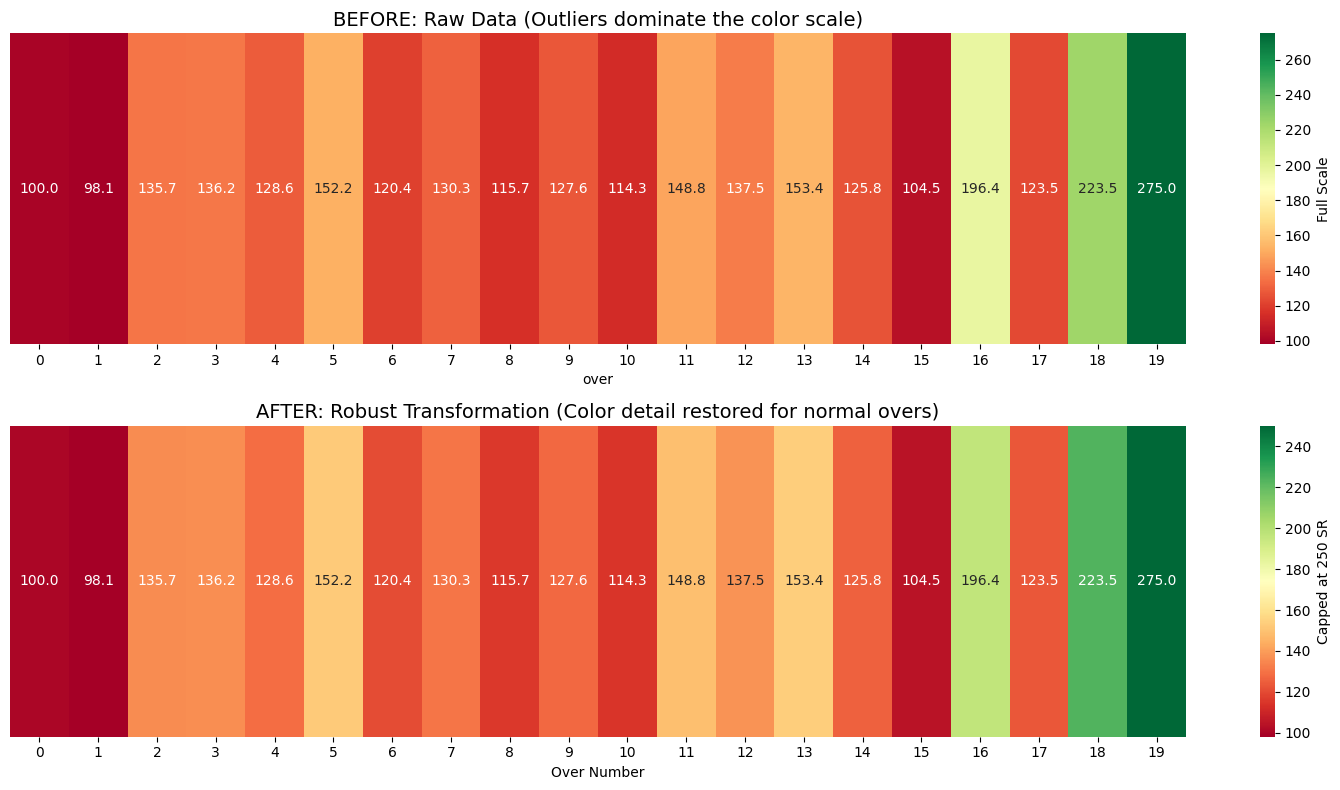

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
deliveries = pd.read_csv('deliveries.csv')

def analyze_true_transformation():
    target_batsman = input("Enter Batsman Name: ")
    
    if target_batsman not in deliveries['batter'].unique():
        print("Batsman not found.")
        return

    # 1. Prepare Data & Handle Missing Overs
    df_batter = deliveries[deliveries['batter'] == target_batsman].copy()
    stats = df_batter.groupby('over').agg(
        runs=('batsman_runs', 'sum'),
        balls=('ball', 'count')
    ).reindex(range(20)).fillna(0)
    
    stats['raw_sr'] = (stats['runs'] / stats['balls'] * 100).fillna(0)

    # 2. Visualization with Forced Normalization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

    # --- PLOT 1: BEFORE (The Skewed Version) ---
    # No limit - one huge outlier will make everything else look red/pale.
    sns.heatmap(stats[['raw_sr']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Full Scale'})
    ax1.set_title(f"BEFORE: Raw Data (Outliers dominate the color scale)", fontsize=14)
    ax1.set_yticks([])

    # --- PLOT 2: AFTER (The Efficiency Transformation) ---
    # We use a 'Robust Max'. We cap the color scale at a realistic high SR (e.g., 250).
    # This allows the color gradient to show detail in the 100-200 range.
    robust_vmax = 250 
    
    sns.heatmap(stats[['raw_sr']].T, annot=True, fmt=".1f", 
                cmap='RdYlGn', ax=ax2, vmax=robust_vmax,
                cbar_kws={'label': f'Capped at {robust_vmax} SR'})
    ax2.set_title(f"AFTER: Robust Transformation (Color detail restored for normal overs)", fontsize=14)
    ax2.set_yticks([])
    ax2.set_xlabel("Over Number")

    plt.tight_layout()
    plt.show()

analyze_true_transformation()